In [11]:
from brian2 import *
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorClass import *

sys.path.append('Tools')
from plottingTools import *
from utils import *

device.reinit()
device.activate()
deviceType = 'cpp_standalone'

if deviceType == 'cpp_standalone':
    set_device(deviceType, build_on_run=False)

runFullSim = True

# import matplotlib
# matplotlib.use('TkAgg')

In [12]:
# Simulation parameters
defaultclock.dt = 0.1*ms

In [13]:
# Setting network parameters
num_neurons = 120
tau = 10*ms
sigma_noise=0.0*mV
V_rest=-70*mV

# neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=5*ms
glob_inh_flag = True


# Connectivity parameters - Cosine
g_cosine = 69.51337004749652*mV
w_inh = -103.92710109941913*mV

I0 = 21.5*mV-sigma_noise*2

In [14]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_vel_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)
            
ringAttractor = RingAttractor(neuron_eq, 
                        num_neurons, 
                        Vth, V_reset, refractory_period,
                        syn_profile='cosine',
                        autapse=False, normalized=True,
                        glob_inh=glob_inh_flag, w_inh=w_inh,
                        g_cosine=g_cosine)


ringAttractor.ring_pool.run_regularly('V = clip(V, V_reset, inf*volt)', dt=defaultclock.dt)

CodeRunner(clock=Clock(dt=100. * usecond, name='ring_neurons_run_regularly_clock_1'), when=start, order=0, name='ring_neurons_run_regularly')

In [15]:
# Setup monitors: spike monitor and state monitor for membrane potential and external input
spikemon = SpikeMonitor(ringAttractor.ring_pool)
inputmon = StateMonitor(ringAttractor.ring_pool, 'I_ext', record=True)  # if you want to check the input

# Set of Brian objects to be added to the network
localObjects = [spikemon, inputmon]

net = Network(ringAttractor.BrianObjects+localObjects)

In [16]:
ringAttractor.ring_pool.I_ext = I0
ringAttractor.ring_pool.I_ext[60] += 1*mV
ringAttractor.ring_pool.I_vel = 0.0
ringAttractor.ring_synapses_asym.vel_on = False
phase1_duration = 1 * second
net.run(phase1_duration)

ringAttractor.ring_synapses_asym.vel_on = True
phase2_duration = 1 * second
net.run(phase2_duration)

ringAttractor.ring_synapses_asym.vel_on = False
phase3_duration = 1 * second
net.run(phase3_duration)

total_duration = phase1_duration + phase2_duration + phase3_duration

In [17]:
if deviceType == 'cpp_standalone':
    device.build(directory = 'model_build', compile=True, run=False, debug=False, clean=False)

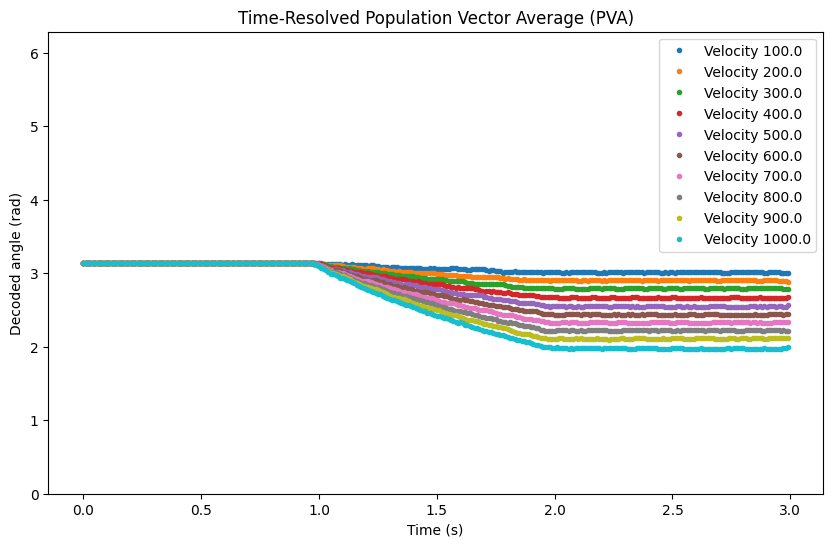

In [18]:
positions = np.linspace(0, 2*np.pi, num_neurons, endpoint=False)
window_size = 50 * ms
step_size = 10 * ms
velocity_input = linspace(100, 1000, 10)
time_windows = []
fig, ax = plt.subplots(figsize=(10, 6))

if deviceType == 'cpp_standalone':
    numIter = 10 if runFullSim else 1
    results = []
    for iter in range(numIter):
        device.run(run_args={ringAttractor.ring_synapses_asym.vel_in: velocity_input[iter]}, results_directory=f'result_{iter}')
        time_resolved_PVA(spikemon, positions, total_duration, num_neurons, window_size=50*ms, ax=ax, label=f"Velocity {velocity_input[iter]}")
        pva_angles, time_windows = computePVATT(spikemon, positions, total_duration, num_neurons, window_size, step_size)
        results.append(pva_angles)
    
plt.show()

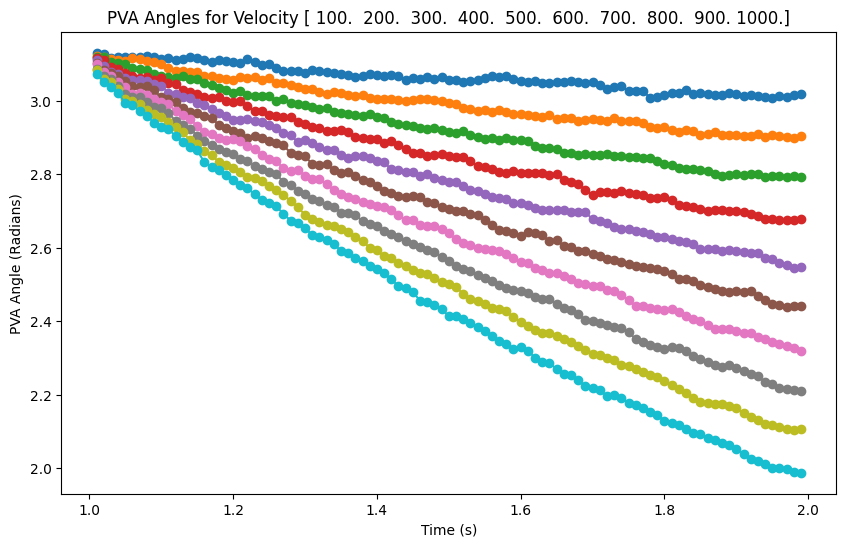

[np.float64(1.229619278978144), np.float64(1.150958888069408), np.float64(1.1193881344209764), np.float64(1.1097943443426304), np.float64(1.1098173170945156), np.float64(1.1068572994687123), np.float64(1.10275850099767), np.float64(1.0990685988412492), np.float64(1.0972544812908192), np.float64(1.097983502497458)]


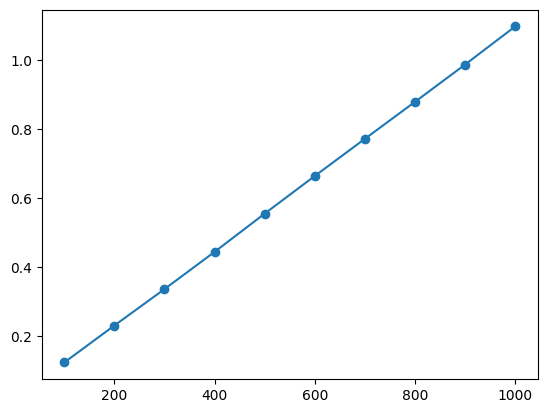

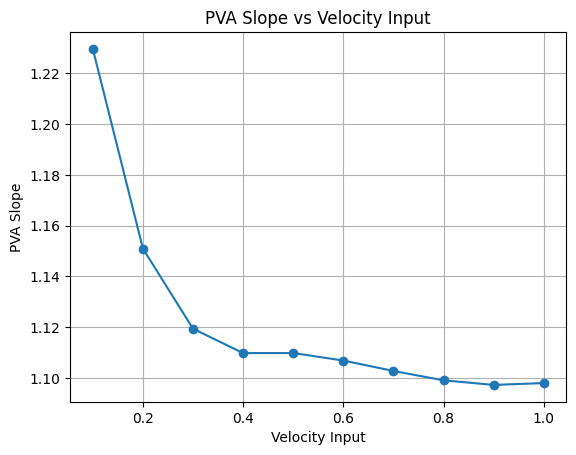

In [19]:
pva_slopes = []
time_windows_au = time_windows.copy()/second
mask = (time_windows_au > 1.0) & (time_windows_au < 2.0)
time_windows_au = time_windows_au[mask]
fig2 = plt.figure(figsize=(10, 6))
for result in results:
    # Calculate the slope of the PVA angles within the masked time window
    pva_slope = np.polyfit(time_windows_au, result[mask], 1)[0]
    pva_slopes.append(pva_slope)
    plt.plot(time_windows_au, result[mask], marker='o')
    plt.xlabel('Time (s)')
    plt.ylabel('PVA Angle (Radians)')
    plt.title(f'PVA Angles for Velocity {velocity_input}')
    plt.grid()

plt.show(block=True)


fig3 = plt.figure()
plt.plot(velocity_input, abs(np.asarray(pva_slopes)), marker='o')
normalized_velocity = velocity_input / np.max(velocity_input)
ratio = [abs(pva_slopes[i]) / normalized_velocity[i] if normalized_velocity[i] != 0 else 0 for i in range(len(normalized_velocity))]
print(ratio)
fig4 = plt.figure()
plt.plot(normalized_velocity, ratio, marker='o')
plt.xlabel('Velocity Input')
plt.ylabel('PVA Slope')
plt.title('PVA Slope vs Velocity Input')
plt.grid()
plt.show(block=True)

In [20]:
if not runFullSim:    
    from matplotlib.ticker import FuncFormatter
    from sympy import Rational


    #+---------------------------------------------------------------------------+
    #|                           Plotting the Results                            |
    #+---------------------------------------------------------------------------+

    # Create a figure with 6 subplots arranged in 3 rows and 2 columns
    fig = plt.figure(figsize=(20,20))

    positions = linspace(0, 2*pi, num_neurons, endpoint=False)
    # Define the formatter function
    def pi_formatter(x, pos):
        # Convert the value to a fraction of pi
        frac = Rational(x).limit_denominator(10)  # Limit denominator to avoid too large fractions
        if frac == 0:
            return r"$0$"
        elif frac == 2:
            return r"$2\pi$"
        else:
            return r"${}\pi$".format(frac)


    # 1. Input Current Plot
    ax1 = fig.add_subplot(3, 2, 1)
    ax1.plot(positions/pi, ringAttractor.ring_pool.I_ext/mV)
    # Set the custom formatter for the x-axis
    ax1.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    ax1.set_title('Input Current')
    ax1.set_xlabel('Position (rad)')
    ax1.set_ylabel('Current (mV)')


    # 2. Raster Plot
    ax2 = fig.add_subplot(3, 2, 2)
    raster_plot(spikemon, ax=ax2, duration=total_duration, num_neurons=num_neurons, y_axisFull=True)


    # 3. Firing Rate Profile Plot
    ax3 = fig.add_subplot(3, 2, 3)
    firing_rate, _ = firing_rate_profile(spikemon, positions/pi, total_duration, ax=ax3)
    ax3.xaxis.set_major_formatter(FuncFormatter(pi_formatter))


    ax4 = fig.add_subplot(3, 2, 4)
    firing_rateInstant, _ = firing_rate_profile(spikemon, positions/pi, total_duration, ax=ax4, instantRate=True)
    ax4.xaxis.set_major_formatter(FuncFormatter(pi_formatter))



    # 4. Polar Plot of the Population Vector Average (PVA)
    ax5 = fig.add_subplot(3, 2, 5, projection='polar')
    polar_plot_PVA(firing_rateInstant, positions, scale=1.2, ax=ax5)

    # 5. Time-Resolved PVA Plot
    ax6 = fig.add_subplot(3, 2, 6)
    _, _ = time_resolved_PVA(spikemon, positions, total_duration, num_neurons,
                            window_size=50*ms, ax=ax6)
    ax6.yaxis.set_major_formatter(FuncFormatter(pi_formatter))



    # Create the 3D instantaneous firing rate plot
    fig, ax = instantRateTT_plot(spikemon, positions, total_duration, num_neurons=num_neurons)

    # Optional: adjust the view angle for better visualization
    ax.view_init(elev=20, azim=-35)

    # # 6. Membrane potential traces
    # ax7 = fig.add_subplot(3, 2, 7)
    # membrane_potential_traces(statemon, total_duration, Vth = Vth, ax=ax7)

    plt.tight_layout()
    plt.show(block=True)